In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import pandas_datareader as data

In [6]:
!pip install yfinance


In [7]:
import pandas as pd

df = pd.read_csv('AAPL_sample.csv', index_col='Date', parse_dates=True)
print(df.head())


                Open      High       Low     Close  Adj Close     Volume
Date                                                                    
1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100178  469033600
1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094952  175884800
1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087983  105728000
1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090160   86441600
1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092774   73449600


In [8]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-06-13,132.869995,135.199997,131.440002,131.880005,131.880005,122207100
2022-06-14,133.130005,133.889999,131.479996,132.759995,132.759995,84784300
2022-06-15,134.289993,137.339996,132.160004,135.429993,135.429993,91533000
2022-06-16,132.080002,132.389999,129.039993,130.059998,130.059998,108123900
2022-06-17,130.070007,133.080002,129.809998,131.559998,131.559998,134118500


In [9]:
df = df.reset_index()
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600


In [10]:
df = df.drop(['Date'], axis = 1)
df.head()

,Open,High,Low,Close,Adj Close,Volume
0,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,0.118862,0.119420,0.118862,0.118862,0.092774,73449600


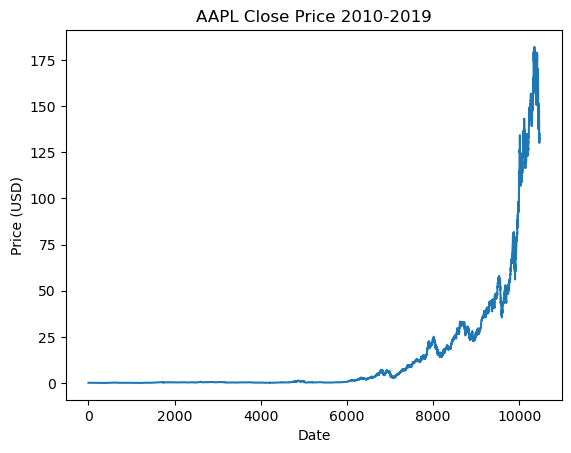

In [11]:
import matplotlib.pyplot as plt

plt.plot(df['Close'])
plt.title('AAPL Close Price 2010-2019')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()



In [12]:
df










,Open,High,Low,Close,Adj Close,Volume
0,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,0.118862,0.119420,0.118862,0.118862,0.092774,73449600
...,...,...,...,...,...,...
10463,132.869995,135.199997,131.440002,131.880005,131.880005,122207100
10464,133.130005,133.889999,131.479996,132.759995,132.759995,84784300
10465,134.289993,137.339996,132.160004,135.429993,135.429993,91533000
10466,132.080002,132.389999,129.039993,130.059998,130.059998,108123900


In [13]:
ma100 = df.Close.rolling(100).mean()
ma100

0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
            ...    
10463    160.944701
10464    160.627201
10465    160.357401
10466    160.041801
10467    159.759601
Name: Close, Length: 10468, dtype: float64

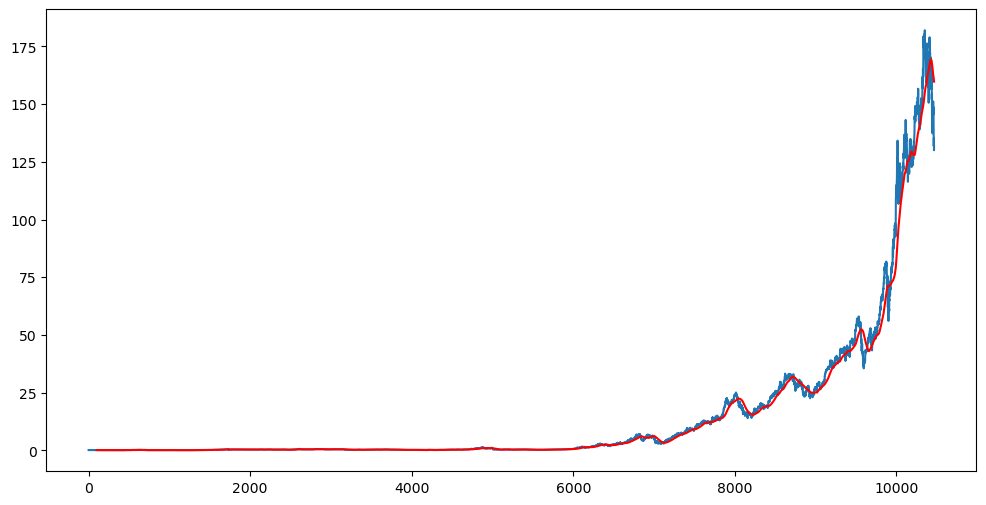

In [14]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')

In [15]:
ma200 = df.Close.rolling(200).mean()
ma200

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
10463    159.30855
10464    159.22935
10465    159.14090
10466    159.03205
10467    158.92730
Name: Close, Length: 10468, dtype: float64

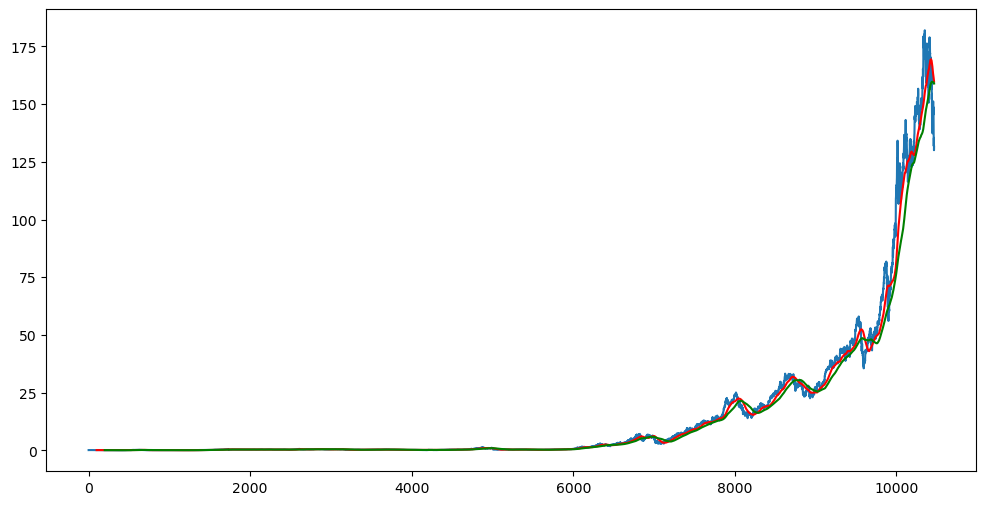

In [16]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')

In [17]:
df.shape

(10468, 6)

In [18]:
#spliting data into training and testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(7327, 1)
(3141, 1)


In [19]:
data_training.head()

,Close
0,0.128348
1,0.121652
2,0.112723
3,0.115513
4,0.118862


In [20]:
data_testing.head()

,Close
7327,7.557500
7328,7.467857
7329,7.558571
7330,7.526071
7331,7.643214


In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [22]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.01068427],
       [0.00978143],
       [0.00857751],
       ...,
       [0.95820191],
       [0.96658081],
       [1.        ]])

In [23]:
x_train = []
y_train = []

In [24]:
data_training_array.shape

(7327, 1)

In [25]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [26]:
x_train.shape

(7227, 100, 1)

In [27]:
#  ml model

In [28]:
pip install keras


Note: you may need to restart the kernel to use updated packages.


In [29]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [30]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential


In [31]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True,))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True,))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
               
model.add(Dropout(0.5))


model.add(Dense(units = 1))




C:\Users\R.REGUNATHAN\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 97s 364ms/step - loss: 0.0137
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 82s 363ms/step - loss: 0.0021
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 133s 325ms/step - loss: 0.0023
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 81s 321ms/step - loss: 0.0018
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 88s 348ms/step - loss: 0.0017
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 82s 348ms/step - loss: 0.0020
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 80s 341ms/step - loss: 0.0016
Epoch 8/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 83s 346ms/step - loss: 0.0015
Epoch 9/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 82s 347ms/step - loss: 0.0015
Epoch 10/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 82s 347ms/step - loss: 0.0013
Epoch 11/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 82s 345ms/step - loss: 0.0016
Epoch 12/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 83s 348ms/step - loss: 0.0013
Epoch 13/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 82s 347ms/step - loss: 0.0013
Epoch 14/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 81s 344ms/step - loss: 0.0016
Epoch 15/50
22

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(10,)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')



C:\Users\R.REGUNATHAN\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
data_testing.head()

,Close
7327,7.557500
7328,7.467857
7329,7.558571
7330,7.526071
7331,7.643214


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(10,)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')





C:\Users\R.REGUNATHAN\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
past_100_days = data_training.tail(100)

In [37]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)


In [38]:
final_df.head()


,Close
0,5.896786
1,5.853929
2,5.911071
3,5.882857
4,5.815357


In [39]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.00111816],
       [0.00087508],
       [0.00119918],
       ...,
       [0.73580677],
       [0.70534914],
       [0.71385686]])

In [40]:
input_data.shape

(3241, 1)

In [41]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])


In [42]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)


(3141, 100, 1)
(3141,)


In [43]:
# making predictions
model = Sequential([
    Dense(64, activation='relu', input_shape=(10,)),
    Dense(1)
])



C:\Users\R.REGUNATHAN\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Normalize the 'Close' prices
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df[['Close']])

# Create training data (e.g., past 60 days)
X_train = []
y_train = []
for i in range(60, len(scaled_data)):
    X_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape for LSTM: [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train, y_train, epochs=10, batch_size=32)


Epoch 1/10


C:\Users\R.REGUNATHAN\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


326/326 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - loss: 0.0022
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 38s 67ms/step - loss: 1.1306e-04
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - loss: 8.8628e-05
Epoch 4/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - loss: 8.1877e-05
Epoch 5/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - loss: 6.3513e-05
Epoch 6/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - loss: 7.1993e-05
Epoch 7/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 6.2009e-05
Epoch 8/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 5.3402e-05
Epoch 9/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - loss: 6.0158e-05
Epoch 10/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - loss: 6.4190e-05


In [49]:
# Split data into training and testing sets (80% train, 20% test)
training_data_len = int(len(scaled_data) * 0.8)

train_data = scaled_data[:training_data_len]
test_data = scaled_data[training_data_len - 60:]  # Include last 60 days of train data


In [50]:
# Prepare X_test and y_test
X_test = []
y_test = scaled_data[training_data_len:]  # Actual values for testing
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)

# Reshape for LSTM input: [samples, time steps, features]
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


In [51]:
y_predicted = model.predict(X_test)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step


In [52]:
y_test

array([[0.10127275],
       [0.1032983 ],
       [0.10301763],
       ...,
       [0.74401091],
       [0.7144991 ],
       [0.72274263]])

In [53]:
y_predicted

array([[0.10264158],
       [0.10199925],
       [0.10175255],
       ...,
       [0.73137754],
       [0.72546166],
       [0.7189053 ]], dtype=float32)

In [54]:
scaler.scale_

array([0.00549569])

In [55]:
scale_factor = 1/0.02134523
y_predicted = y_predicted * scale_factor
y_test = y_test * scale_factor


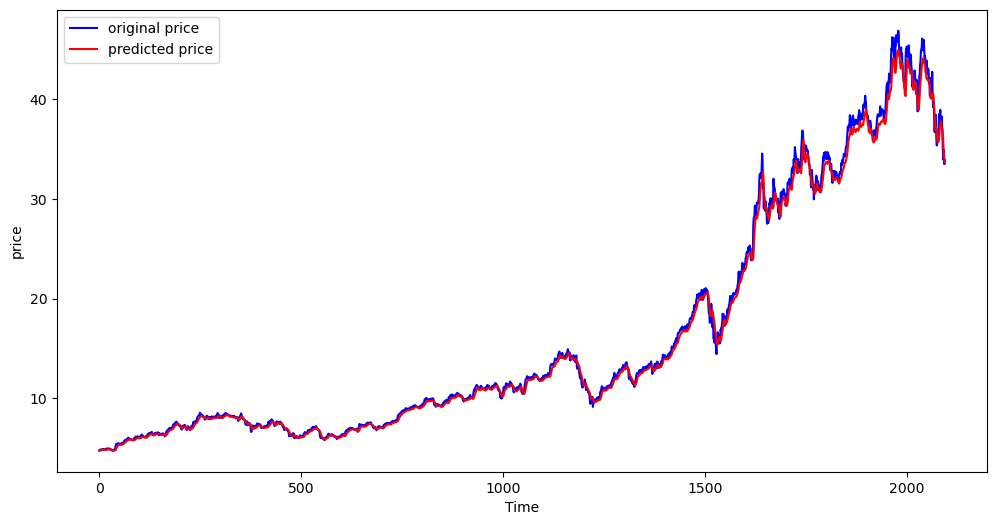

In [56]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b',label = 'original price')
plt.plot(y_predicted, 'r' ,label = 'predicted price')
plt.xlabel('Time')
plt.ylabel('price')
plt.legend()
plt.show()